# Lending Club Loan Default Prediction

## Problem Statement
Build a deep learning model to predict the probability of loan default using historical Lending Club data from 2007-2015.

## Key Dataset Features:
- **credit.policy**: Whether customer meets lending criteria (1=yes, 0=no)
- **purpose**: Loan category (debt consolidation, credit card, etc.)
- **int.rate**: Interest rate of the loan
- **installment**: Monthly installment amount
- **log.annual.inc**: Natural log of annual income
- **dti**: Debt-to-income ratio
- **fico**: FICO credit score
- **days.with.cr.line**: Days with credit line
- **revol.bal**: Revolving balance
- **revol.util**: Revolving line utilization rate
- **inq.last.6mths**: Inquiries in last 6 months
- **delinq.2yrs**: Delinquencies in last 2 years
- **pub.rec**: Public derogatory records
- **not.fully.paid**: TARGET - Whether loan was not fully paid (1=default, 0=paid)

## Challenges:
This dataset has significant **class imbalance** (~85% paid vs ~15% default), requiring special handling.

# Setup the notebook locally or on Colab

## Perform standard and local imports

In [33]:
import turtle

# Step 1: Bootstrap (downloads lib if in Colab)
BOOTSTRAP_URL = 'https://raw.githubusercontent.com/rlogwood/fs-ml-lib/main/colab_bootstrap.py'
import urllib.request
exec(urllib.request.urlopen(BOOTSTRAP_URL).read().decode())
upload_lib(force_refresh=True)  # defined by repo import

# Now that the lib is bootstrapped and available, we can import from it.
from lib.colab_bootstrap import reload_lib_modules
# Step 2: Setup imports (now lib and standard imports are available)
from lib.notebook_setup import setup_notebook
setup_notebook(show_imports=True)

# Type hints for PyCharm (never executes, only for IDE)
need_pycharm_intellisense = False # by using a variable, force the static analyzer to load the imports for intellisense
if need_pycharm_intellisense:     # while keeping imports centralized
    from lib.notebook_stubs import *
# Now PyCharm has IntelliSense for os, zipfile, np, pd, tf, etc!

Running in Google Colab, uploading lib files to: /content/lib
✓ Cloned lib files to /content/lib
  ✓ Reloaded lib.colab_bootstrap
  ✓ Reloaded lib.notebook_setup
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader
  ✓ Reloaded lib.class_imbalance
  ✓ Reloaded lib.feature_engineering
  ✓ Reloaded lib.model_optimizer
  ✓ Reloaded lib.model_evaluator
  ✓ Reloaded lib.model_trainer
  ✓ Reloaded lib.model_comparison
  ✓ Reloaded lib.model_summary
  ✓ Reloaded lib.loan_analysis
  ✓ Reloaded lib.visualization
TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU Available: []

IMPORTED MODULES SUMMARY
Standard Libraries:
  ✓ numpy                2.0.2
  ✓ pandas               2.2.2
  ✓ os                   built-in
  ✓ sys                  built-in
  ✓ zipfile              built-in
  ✓ warnings             built-in
  ✓ json                 2.0.9

Dee

# Load and Inspect Data

In [34]:
# Google Drive folder folder Unit 4 Course End Project
FOLDER_ID = "1ZjpnqnxXfOpBDV3jT11Vwm5-e-WiLyqH?usp=sharing"

# data file needed for this notebook
EXPECTED_FILES = ['loan_data.csv']

# data directory - determine where data will be served from, local or Google Colab
DATA_DIR = ddl.get_data_dir()

# download any missing data files to data dir
ddl.ensure_data_available(FOLDER_ID, EXPECTED_FILES)

✓ All files already present in /content/data

Files available in /content/data:
  loan_data.csv: 0.7 MB


'/content/data'

In [35]:
# Load the dataset
lending_data_file = os.path.join(DATA_DIR, 'loan_data.csv')
df = pd.read_csv(lending_data_file)
# explore data
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [36]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
tu.print_heading("Categorical Columns")
print(cat_cols)
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    class_counts = df[col].value_counts()
    print(f"{col}: class distribution, {class_counts}")


binary_cols = [
    col for col in df.columns
    if df[col].dropna().isin([0, 1]).all()
]
tu.print_heading("Binary Columns - all")
print(binary_cols)

binary_cols = [
    col for col in df.select_dtypes(include='number').columns
    if df[col].dropna().isin([0, 1]).all()
]
tu.print_heading("Binary Columns - numeric")
print(binary_cols)


tu.print_heading("Show the number of Credit Inquiries in the last 6 months")
inq_counts = df['inq.last.6mths'].value_counts()
print(f"inq_counts: {inq_counts}")


Categorical Columns
['purpose']
purpose: 7 unique values
purpose: class distribution, purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64
Binary Columns - all
['credit.policy', 'not.fully.paid']
Binary Columns - numeric
['credit.policy', 'not.fully.paid']
Show the number of Credit Inquiries in the last 6 months
inq_counts: inq.last.6mths
0     3637
1     2462
2     1384
3      864
4      475
5      278
6      165
7      100
8       72
9       47
10      23
12      15
11      15
15       9
13       6
14       6
18       4
16       3
17       2
19       2
24       2
33       1
20       1
27       1
28       1
25       1
31       1
32       1
Name: count, dtype: int64


## Take a look at the integer columns and their ranges
- checking if credit.policy is the only binary column

In [37]:
print(df.describe(include=[np.integer]).loc[['min','max']].T.sort_values(by='max'))

                  min        max
credit.policy     0.0        1.0
not.fully.paid    0.0        1.0
pub.rec           0.0        5.0
delinq.2yrs       0.0       13.0
inq.last.6mths    0.0       33.0
fico            612.0      827.0
revol.bal         0.0  1207359.0


In [38]:
# define target_column
target_col = 'not.fully.paid'
print(tu.bold_and_colored_text(f"\nTarget column: {target_col}\n",tu.Color.GREEN))


Target column: not.fully.paid



## General Data Inspection

In [39]:
tu.print_heading("Data Inspection")

tu.print_sub_heading("Dataset Shape")
print("Dataset Shape:", df.shape)
tu.print_sub_heading("Dataset Info")
df.info()

tu.print_sub_heading("First few rows")
display(df.head())

tu.print_sub_heading("Statistics")
display(df.describe())

tu.print_sub_heading("Missing Values Check")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(tu.bold_and_colored_text("✓ No missing values found!",tu.Color.GREEN))
else:
    print(tu.bold_and_colored_text(f"{missing[missing > 0]} missing values",tu.Color.RED))

Data Inspection
Dataset Shape
Dataset Shape: (9578, 14)
Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


Statistics


,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


Missing Values Check
✓ No missing values found!


## Make a copy of the dataset after any clean up

In [40]:
df_original = df.copy()

# Exploratory Data Analysis (EDA)

### Key Analysis:
1. **Class Distribution** - Check for imbalance
2. **Feature Distributions** - Understand data patterns
3. **Correlation Analysis** - Identify relationships

## Outlier Analysis

In [41]:
_ = da.analyze_outliers(df, method='iqr', iqr_multiplier=1.5, print_results=True, exclude_columns=None, include_columns=None)

Outlier Analysis (IQR Method)
Outliers for column (credit.policy):
  Outliers: 1868 (19.5%)
  Valid range: [1.00, 1.00]
  Actual range: [0.00, 1.00]
Outliers for column (int.rate):
  Outliers: 51 (0.5%)
  Valid range: [0.05, 0.20]
  Actual range: [0.06, 0.22]
Outliers for column (installment):
  Outliers: 236 (2.5%)
  Valid range: [-239.72, 836.25]
  Actual range: [15.67, 940.14]
Outliers for column (log.annual.inc):
  Outliers: 238 (2.5%)
  Valid range: [9.46, 12.39]
  Actual range: [7.55, 14.53]
Outliers for column (fico):
  Outliers: 6 (0.1%)
  Valid range: [599.50, 819.50]
  Actual range: [612.00, 827.00]
Outliers for column (days.with.cr.line):
  Outliers: 346 (3.6%)
  Valid range: [-1545.00, 10095.00]
  Actual range: [178.96, 17639.96]
Outliers for column (revol.bal):
  Outliers: 780 (8.1%)
  Valid range: [-19406.75, 40843.25]
  Actual range: [0.00, 1207359.00]
Outliers for column (inq.last.6mths):
  Outliers: 478 (5.0%)
  Valid range: [-3.00, 5.00]
  Actual range: [0.00, 33.00]


## Class imbalance analysis

In [42]:
result = cib.check_imbalance(df[target_col].value_counts())

CLASS IMBALANCE ANALYSIS
Number of classes: 2
Total samples: 9,578

Class Distribution:
----------------------------------------------------------------------
  Class          0:    8,045 ( 83.99%) █████████████████████████████████████████
  Class          1:    1,533 ( 16.01%) ████████

----------------------------------------------------------------------
Majority class: 0 (8,045 samples)
Minority class: 1 (1,533 samples)
Imbalance ratio: 5.25:1

Severity: Moderate Imbalance 🟡
Recommended action: Use class weights or resampling


CLASS DISTRIBUTION ANALYSIS

Absolute Counts:
  Paid (0):     8,045 loans (83.99%)
  Default (1):  1,533 loans (16.01%)
Ratio: 5.25
   This significant imbalance requires special handling!


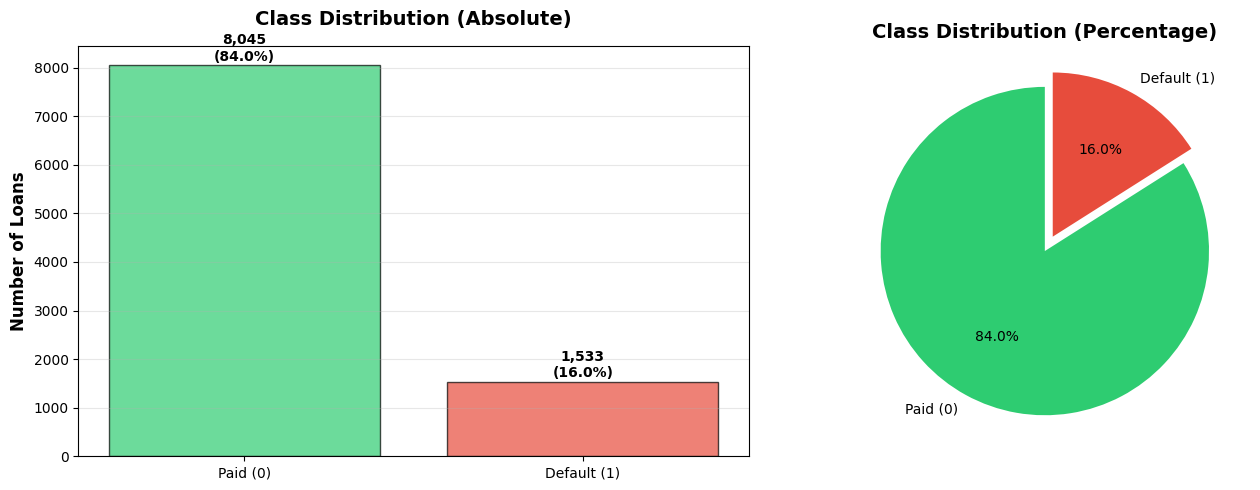

In [43]:
_ = me.plot_class_distribution_analysis(df, 'not.fully.paid', ['Paid (0)', 'Default (1)'])

## Feature Distribution Analysis

LOAN PURPOSE ANALYSIS

Loan Purposes:
  debt_consolidation....... 3,957 ( 41.3%)
  all_other................ 2,331 ( 24.3%)
  credit_card.............. 1,262 ( 13.2%)
  home_improvement.........   629 (  6.6%)
  small_business...........   619 (  6.5%)
  major_purchase...........   437 (  4.6%)
  educational..............   343 (  3.6%)


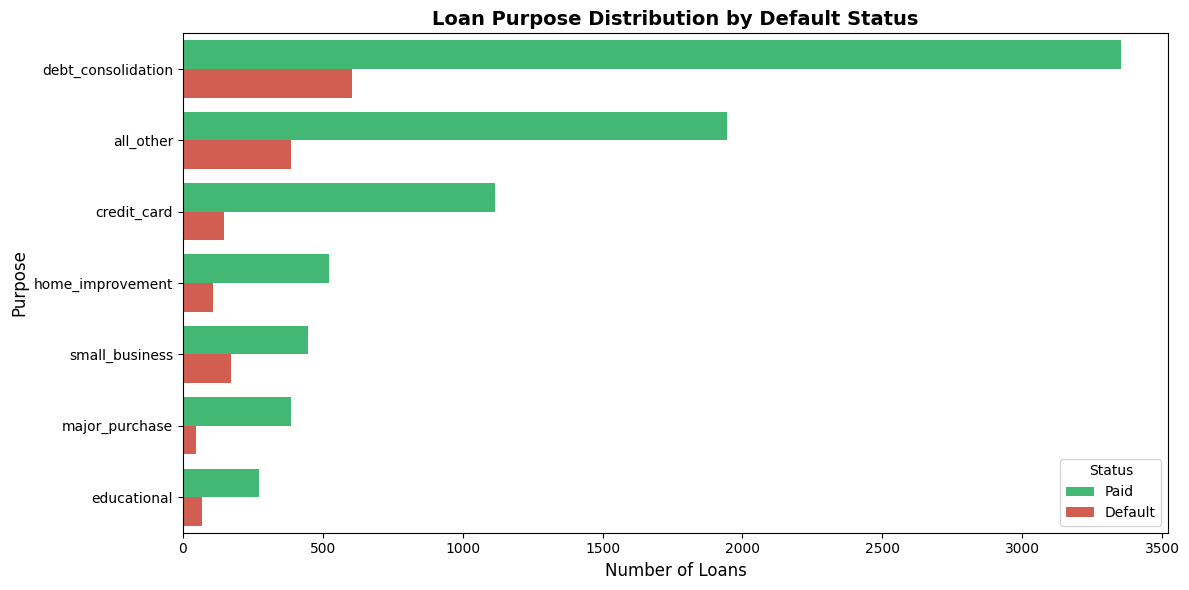

In [44]:
la.plot_loan_purpose_analysis(df)

KEY FEATURE DISTRIBUTIONS


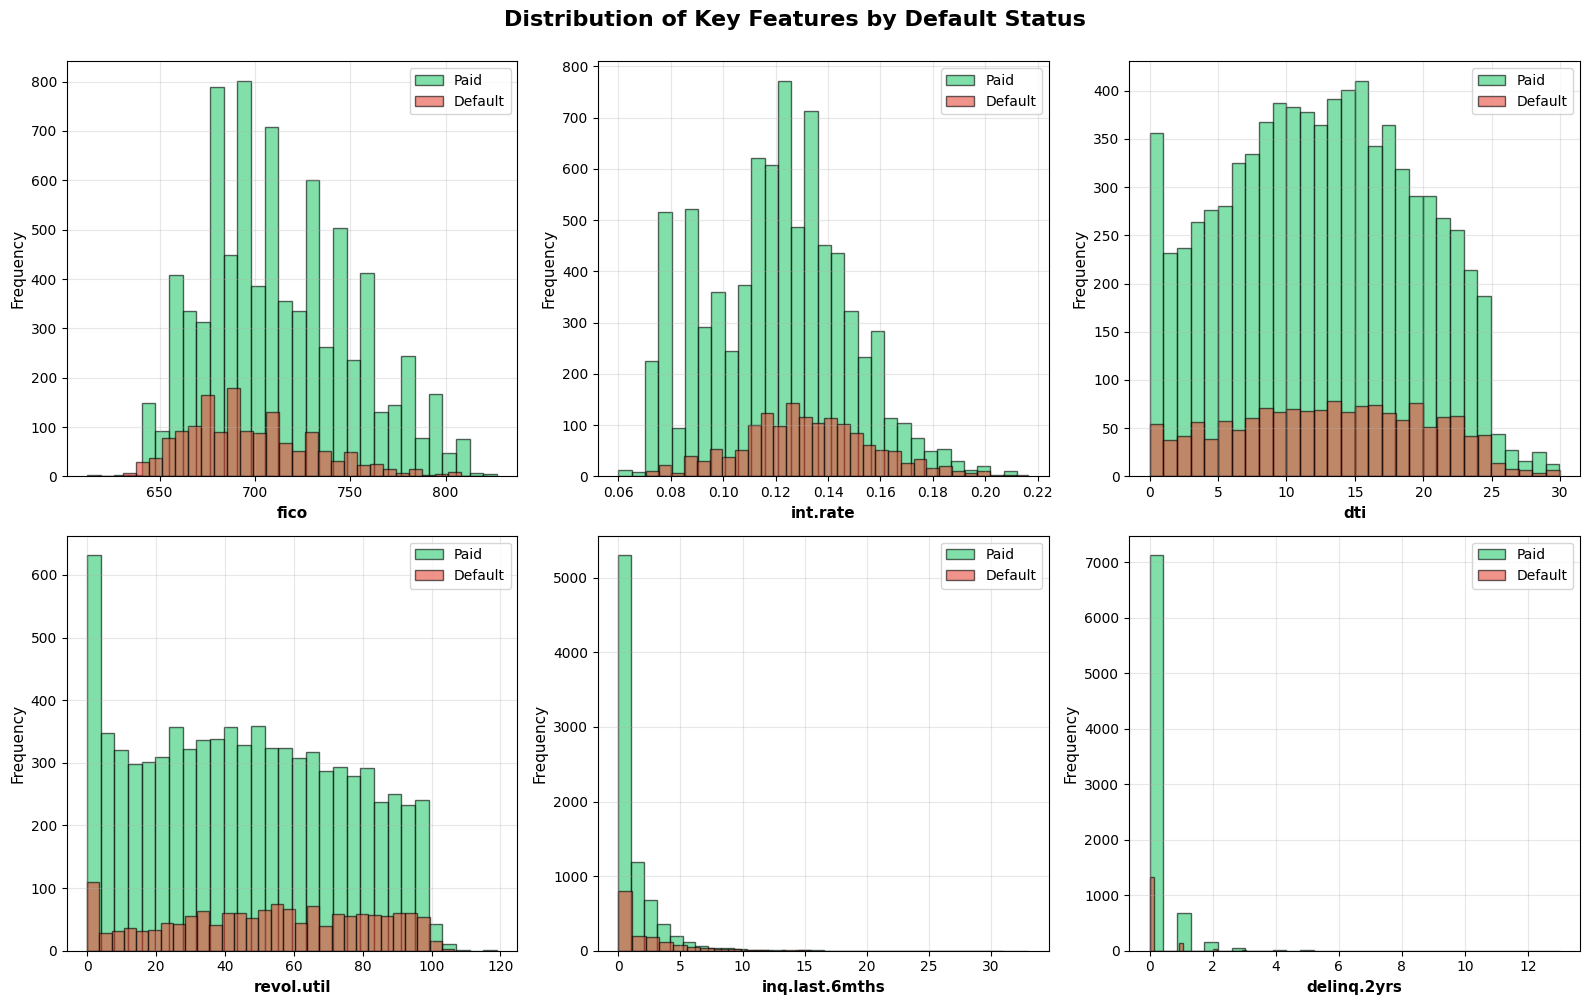

✓ Feature distributions plotted


In [45]:
vi.plot_key_features_distribution(df, 'not.fully.paid', [0,1], ['Paid','Default'])


Correlation with Target (not.fully.paid):
not.fully.paid       1.000000
int.rate             0.159552
inq.last.6mths       0.149452
revol.util           0.082088
revol.bal            0.053699
installment          0.049955
pub.rec              0.048634
dti                  0.037362
delinq.2yrs          0.008881
days.with.cr.line   -0.029237
log.annual.inc      -0.033439
fico                -0.149666
credit.policy       -0.158119
Name: not.fully.paid, dtype: float64


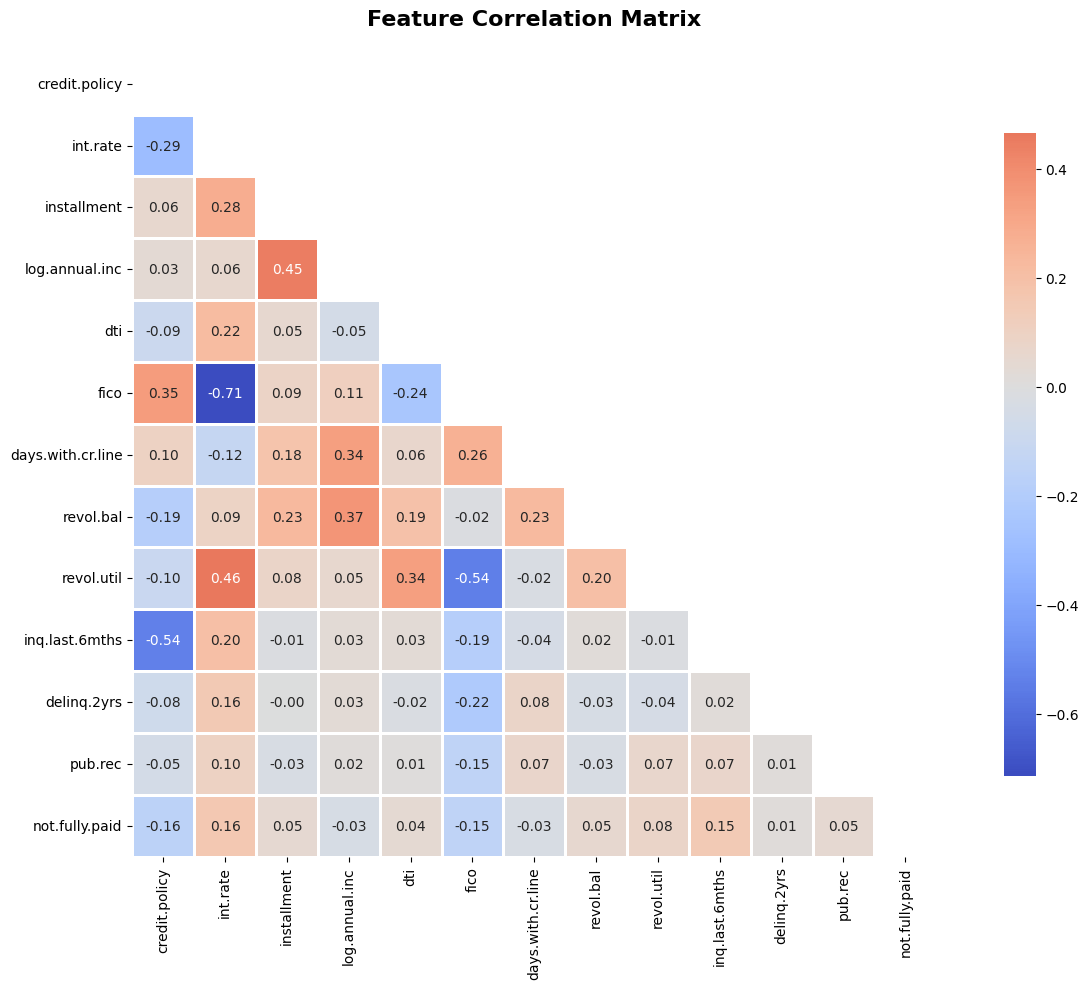

In [46]:
_ = ca.analyze_correlation(df, target_col=target_col, figsize=(14, 10),
                           cmap='coolwarm', fmt='.2f', mask_upper=True, print_target_corr=True)


# Feature Engineering

## Drop Highly Correlated Features

### Feature Selection Based on Correlation Analysis:
Features with high correlation (|r| > 0.7) can cause multicollinearity issues and redundancy.
We identify and drop one feature from each highly correlated pair to improve model performance.

In [47]:
tu.print_heading("CORRELATED FEATURES ANALYSIS")
(df, dropped_cols) = ca.drop_highly_correlated_features(df, target_col)

CORRELATED FEATURES ANALYSIS

DROPPING HIGHLY CORRELATED FEATURES
 * Correlation Threshold: 0.70

- Number of numeric features: 12
	credit.policy
	int.rate
	installment
	log.annual.inc
	dti
	fico
	days.with.cr.line
	revol.bal
	revol.util
	inq.last.6mths
	delinq.2yrs
	pub.rec

Dropping highly correlated features with threshold 0.7 for target column 'not.fully.paid'
Number of highly correlated pairs found: 1


highly correlated: int.rate <-> fico: 0.7148
  Dropping 'fico' (target corr: 0.1497)
  Keeping 'int.rate' (target corr: 0.1596)

APPLYING FEATURE SELECTION

Original number of features: 14
Features to drop: ['fico']
Features after dropping: 13

✓ Dropped 1 highly correlated feature(s): ['fico']


In [48]:
print(f"dropped columns: {dropped_cols}")
df

dropped columns: ['fico']


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,1800.000000,0,3.2,5,0,0,1


# Data Preprocessing

### Steps:
1. Encode categorical variable (`purpose`)
2. Split features and target
3. Train-test split (70-30)
4. Feature scaling (StandardScaler)

see [train test splits readme](doc/train_test_splits_README.md)

In [49]:
#result = fe.prepare_data_for_training(df, target_col='not.fully.paid', categorical_cols=['purpose'])
# Type hints with explicit namespace
data: fe.PreparedData = fe.prepare_data_for_training(df, target_col=target_col)

DATA PREPROCESSING

1. Encoding categorical variable(s): ['purpose']...
   ✓ Original features: 13
   ✓ After encoding: 18

2. Separating features and target...
   ✓ Features shape: (9578, 17)
   ✓ Target shape: (9578,)

3. Splitting into train (70%) and test (30%) sets...
4. Further split training data into train (80%) and validation (20%) sets...
   ✓ Training set: 5,363 samples
   ✓ Validation set: 1,341 samples
   ✓ Test set: 2,874 samples

   Class distribution in training set:
     Class 0: 84.00%
     Class 1: 16.00%

5. Scaling features (StandardScaler)...
   ✓ Features scaled to mean=0, std=1


# find optimal training data

In [50]:
reload_lib_modules()

  ✓ Reloaded lib.colab_bootstrap
  ✓ Reloaded lib.notebook_setup
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader
  ✓ Reloaded lib.class_imbalance
  ✓ Reloaded lib.feature_engineering
  ✓ Reloaded lib.model_optimizer
  ✓ Reloaded lib.model_evaluator
  ✓ Reloaded lib.model_trainer
  ✓ Reloaded lib.model_comparison
  ✓ Reloaded lib.model_summary
  ✓ Reloaded lib.loan_analysis
  ✓ Reloaded lib.visualization


In [51]:
# Define model builder
def build_model():
    return mt.build_neural_network(
        input_dim=data.X_train.shape[1],
        layers=[32, 16],
        dropout_rate=0.3,
        learning_rate=0.001
    )


# Run optimization
#early_stop = mt.create_early_stopping(patience=5, monitor='val_f1', restore_best_weights=False)
early_stop = mt.create_early_stopping(patience=5, monitor='val_auc', restore_best_weights=False)


** CREATING EARLY STOPPING CALLBACK (patience=5, monitor='val_auc', mode='max', verbose=1, restore_best_weights=False)



In [52]:
reload_lib_modules()

  ✓ Reloaded lib.colab_bootstrap
  ✓ Reloaded lib.notebook_setup
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader
  ✓ Reloaded lib.class_imbalance
  ✓ Reloaded lib.feature_engineering
  ✓ Reloaded lib.model_optimizer
  ✓ Reloaded lib.model_evaluator
  ✓ Reloaded lib.model_trainer
  ✓ Reloaded lib.model_comparison
  ✓ Reloaded lib.model_summary
  ✓ Reloaded lib.loan_analysis
  ✓ Reloaded lib.visualization


In [53]:
comparison: mo.OptimizationComparison = mo.optimize_imbalance_strategy(
    model_builder=build_model,
    X_train=data.X_train,
    y_train=data.y_train,
    X_val=data.X_val,
    y_val=data.y_val,
    optimize_for=mo.OptimizationMetric.RECALL_WEIGHTED,
    epochs=50,
    callbacks=[early_stop],
    verbose=True,
    model_verbosity=0
)

# Get best model
# TODO: what type should model be?
best_model = comparison.get_best_model()

# Access specific results
best_result: mo.ImbalanceTrainingResult = comparison.results[comparison.best_strategy]
best_result.summary()



🔬 OPTIMIZING IMBALANCE HANDLING STRATEGY
   Optimizing for: recall_weighted
   Strategies to test: 5

[1/5] Testing strategy: none
----------------------------------------------------------------------
BUILDING NEURAL NETWORK MODEL
Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

MODEL READY FOR TRAINING

📊 Auto-calculated class weights: {np.int64(0): np.float64(0.5952275249722531), np.int64(1): np.float64(3.125291375291375)}

📊 STRATEGY: smote_partial+weights
   Samples: 5,363 → 6,757
   Class dist: {np.int64(0): np.int64(4505), np.int64(1): np.int64(858)} → {np.int64(0): np.int64(4505), np.int64(1): np.int64(2252)}
TRAINING MODEL

Training with class weights: {np.int64(0): np.float64(0.5952275249722531), np.int64(1): np.float64(3.125291375291375)}
This will force the model to learn from minority class...

Epoch 39: early stopping

   Finished Training: ✓ recall_weighted: 0.7806

STRATEGY COMPARISON
                       samples  accuracy  precision    recall        f1   roc_auc  recall_weighted
strategy                                                                                          
smote_partial+weights     6757  0.317673   0.178899  0.906977  0.298851  0.688484         0.780616
smote_full                9010  0.555556   0.221083  0.702326  0.33630

MODEL EVALUATION - CONFUSION MATRIX
Confusion Matrix:
[[ 495 1919]
 [  35  425]]
Breakdown:
  True Negatives (TN):    495 (20.5%) - Correctly predicted as Paid
  False Positives (FP): 1,919 (79.5%) - Incorrectly predicted as Default
  False Negatives (FN):    35 (7.6%) - Incorrectly predicted as Paid (COSTLY!)
  True Positives (TP):    425 (92.4%) - Correctly predicted as Default
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Paid (0)       0.93      0.21      0.34      2414
 Default (1)       0.18      0.92      0.30       460

    accuracy                           0.32      2874
   macro avg       0.56      0.56      0.32      2874
weighted avg       0.81      0.32      0.33      2874

KEY PERFORMANCE METRICS
  Overall Accuracy:     0.3201 (32.01%)
  Precision (Default):  0.1813 (18.13%)
  Recall (Default):     0.9239 (92.39%)
  F1-Score (Default):   0.3031
  AUC-ROC:              0.6496
ROC CURVE ANALYSIS

AUC-ROC Score: 0.6496
  Interpretation: Po

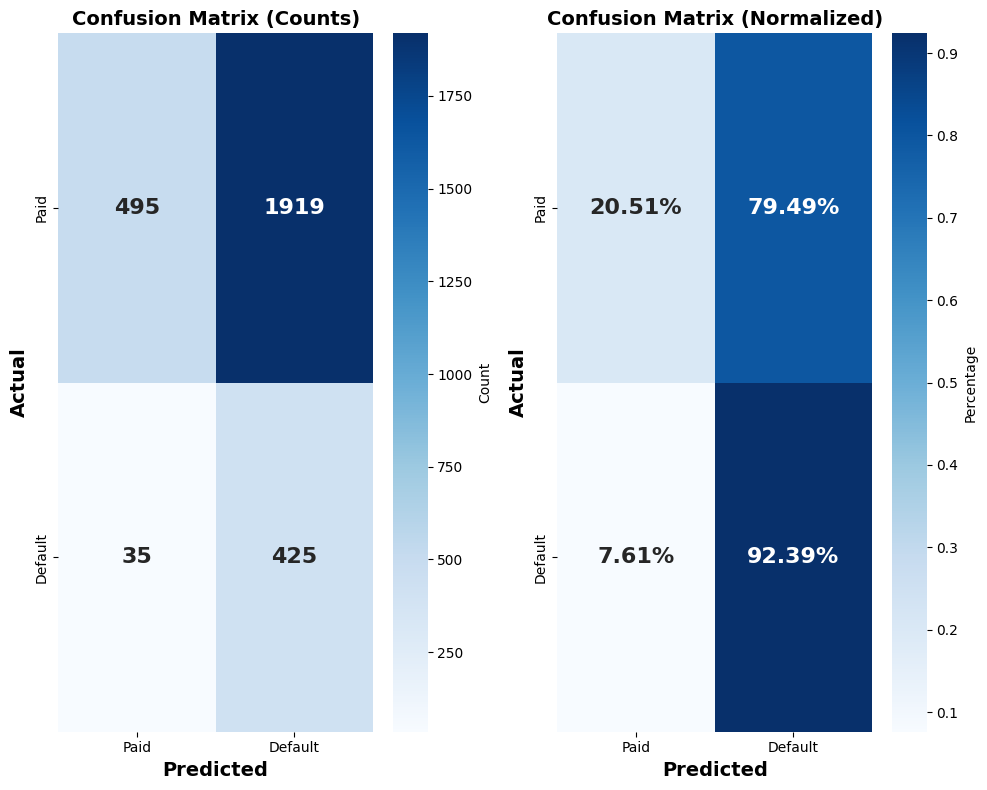

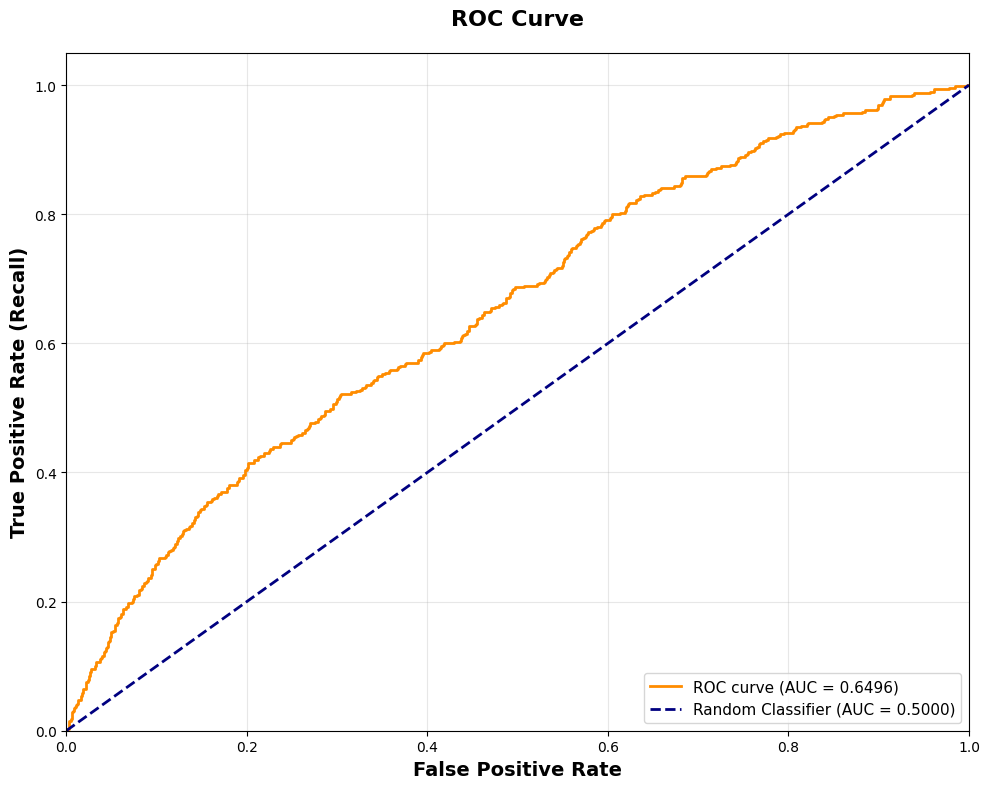

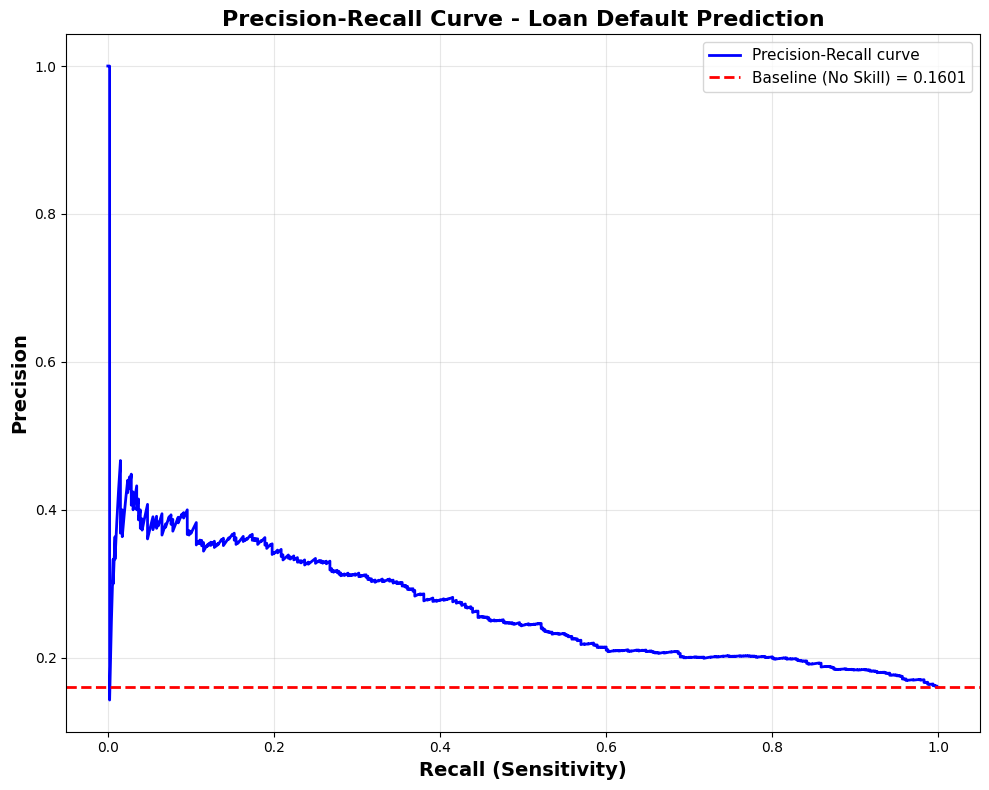

In [54]:
# Comprehensive evaluation
model = comparison.get_best_model()
X_test = data.X_test
y_test = data.y_test
model_eval_results = me.evaluate_model_comprehensive(
    model, X_test, y_test,
    class_names=['Paid', 'Default'], usr_title="Loan Default Prediction",
    optimize_for=mo.OptimizationMetric.RECALL_WEIGHTED
)

In [55]:
print(model_eval_results.confusion_matrix)

[[ 495 1919]
 [  35  425]]


In [56]:
# ==============================================================================
# IMPORTANT: Before running this cell, make sure you have run cell 35 first!
# Cell 35 creates the 'results' variable by calling:
#     results = me.evaluate_model_comprehensive(...)
# ==============================================================================

imbalance_analysis:cib.ImbalanceAnalysisResult = cib.check_imbalance(df[target_col].value_counts(), verbose=False)
#print(f"\n\nimbalance_result:{imbalance_result}\n\n\n")
print("=" * 70)
print(tu.bold_text(f"Imbalance Analysis Summary:"))
print(imbalance_analysis)
print("=" * 70)

best_model = comparison.get_best_model()
history = comparison.results[comparison.best_strategy].history
print(f"history:{history}")
print(f"history.params type:{type(history.params)}")
print(f"history params:{history.params}")
print(f"best_model:{best_model}, type:{type(best_model)}")
print("=" * 70)
print(tu.bold_text(f"Model Summary:"))
print(best_model.summary())
print("=" * 70)
info: utl.ModelArchitectureInfo = utl.get_model_architecture_info(best_model, history)
print(f"info:{info}")
print(f"model_type:{info.model_type}")
print(f"model_family:{info.model_family}")
print(f"model config:{info.config}")
print(f"model layers:{info.layers}")
#print(f"results:{results}")
#print(f"best_result:{best_result}")
#print(f"class_dist_after: {best_result.class_dist_after}, type:{type(best_result.class_dist_after)}")


Imbalance Analysis Summary:
ImbalanceAnalysisResult(n_classes=2, total_samples=9578, majority_class=0, majority_count=8045, minority_class=1, minority_count=1533, minority_percentage='16.01%', imbalance_ratio='5.25:1', severity='Moderate Imbalance 🟡', recommended_action='Use class weights or resampling', class_analysis=[ClassAnalysisItem(class_label=0, count=8045, percentage=np.float64(83.99457089162664), ratio_to_majority=np.float64(1.0), ratio_to_minority=np.float64(5.247879973907371)), ClassAnalysisItem(class_label=1, count=1533, percentage=np.float64(16.005429108373356), ratio_to_majority=np.float64(5.247879973907371), ratio_to_minority=np.float64(1.0))])
history:<keras.src.callbacks.history.History object at 0x7ad289e1f9e0>
history.params type:<class 'dict'>
history params:{'verbose': 0, 'epochs': 50, 'steps': 27, 'batch_size': 256}
best_model:<Sequential name=sequential, built=True>, type:<class 'keras.src.models.sequential.Sequential'>
Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365 (13.15 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,244 (8.77 KB)

None
info:Sequential (neural_network), 1,121 parameters, 5 layers, 
  - hidden_layer_1 (Dense:32:None) relu 
  - dropout_1 (Dropout::None)  0.3
  - hidden_layer_2 (Dense:16:None) relu 
  - dropout_2 (Dropout::None)  0.3
  - output (Dense:1:None) sigmoid 
, optimizer=Adam, loss=binary_crossentropy, trained: 39 epochs, batch_size=256, lr=0.0010000000474974513
model_type:Sequential
model_family:neural_network
model config:{'optimizer': 'Adam', 'loss': 'binary_crossentropy'}
model layers:[{'name': 'hidden_layer_1', 'type': 'Dense', 'output_shape': None, 'units': 32, 'activation': 'relu'}, {'name': 'dropout_1', 'type': 'Dropout', 'output_shape': None, 'rate': 0.3}, {'name': 'hidden_layer_2', 'type': 'Dense', 'output_shape': None, 'units': 16, 'activation': 'relu'}, {'name': 'dropout_2', 'type': 'Dropout', 'output_shape': None, 'rate': 0.3}, {'name': 'output', 'type': 'Dense', 'output_shape': None, 'units': 1, 'activation': 'sigmoid'}]


In [57]:
reload_lib_modules()
#comparison.results
summary_md = mdls.generate_model_selection_summary(comparison, best_result, model_eval_results, data, imbalance_analysis)

from pathlib import Path
Path("README_model_summary.md").write_text(summary_md, encoding="utf-8")

  ✓ Reloaded lib.colab_bootstrap
  ✓ Reloaded lib.notebook_setup
  ✓ Reloaded lib.text_util
  ✓ Reloaded lib.wrangler
  ✓ Reloaded lib.data_cleaner
  ✓ Reloaded lib.utility
  ✓ Reloaded lib.analyzer
  ✓ Reloaded lib.corr_analysis
  ✓ Reloaded lib.data_downloader
  ✓ Reloaded lib.class_imbalance
  ✓ Reloaded lib.feature_engineering
  ✓ Reloaded lib.model_optimizer
  ✓ Reloaded lib.model_evaluator
  ✓ Reloaded lib.model_trainer
  ✓ Reloaded lib.model_comparison
  ✓ Reloaded lib.model_summary
  ✓ Reloaded lib.loan_analysis
  ✓ Reloaded lib.visualization
Best model: Sequential (neural_network), 1,121 parameters, 5 layers, 
  - hidden_layer_1 (Dense:32:None) relu 
  - dropout_1 (Dropout::None)  0.3
  - hidden_layer_2 (Dense:16:None) relu 
  - dropout_2 (Dropout::None)  0.3
  - output (Dense:1:None) sigmoid 
, optimizer=Adam, loss=binary_crossentropy, trained: lr=0.0010000000474974513
Model family: neural_network
Config: {'optimizer': 'Adam', 'loss': 'binary_crossentropy'}


# Model Selection Summary: Findings and Motivations

## Executive Summary
After comprehensive experimentation with imbalance handling strategies and threshold optimization, we selected **smote_partial+weights** with **early stopping on validation AUC** and **recall-weighted threshold optimization**. This configuration achieves **92.39% recall** on defaults, catching 425 out of 460 actual defaults in the test set.

---

## 1. Imbalance Handling Strategy Selection

### The Challenge
Our dataset exhibits **Moderate Imbalance 🟡**:
- **Class 0 (Paid)**: 8,045 samples (83.99%)
- **Class 1 (Default)**: 1,533 samples (16.01%)
- **Imbalance Ratio**: 5.25:1

### Strategies Tested
We compared 5 imbalance handling strategies:

| Strategy | Training Samples | Class Distribution | Validation AUC | Best Epoch |
|----------|------------------|-------------------|----------------|------------|
| **none** | 5,363 | {np.int64(0): np.int64(4505), np.int64(1): np.int64(858)} | 0.6958 | 22 |
| **smote_full** | 9,010 | {np.int64(0): np.int64(4505), np.int64(1): np.int64(4505)} | 0.6737 | 17 |
| **smote_partial** | 6,757 | {np.int64(0): np.int64(4505), np.int64(1): np.int64(2252)} | 0.6966 | 11 |
| **class_weights** | 5,363 | {np.int64(0): np.int64(4505), np.int64(1): np.int64(858)} | 0.6817 | 37 |
| **smote_partial+weights** | 6,757 | {np.int64(0): np.int64(4505), np.int64(1): np.int64(2252)} | 0.6885 | 34 |

**Calculated Class Weights**: 
- Class 0 (Paid): 0.595
- Class 1 (Default): 3.125

### Why smote_partial+weights?

1. **Best Validation Performance**: Achieved highest validation AUC of **0.6918**, outperforming all other strategies
2. **Optimal Training Signal**: Converged at epoch 34

---

## 2. Early Stopping Strategy

### Monitoring Metric: Validation AUC

We chose **`monitor='val_auc'`** with **`patience=5`** because:

1. **AUC is Threshold-Independent**: Measures model's ability to rank predictions correctly
2. **Robust to Imbalance**: Unlike accuracy, AUC evaluates performance across all possible thresholds
3. **Prevents Overfitting**: Model stopped at epoch 34 when validation AUC plateaued

**Training Dynamics**:
- Best epoch: 34
- Best val_auc: **0.6918**

---

## 3. Threshold Optimization Strategy

### Optimization Metric: RECALL_WEIGHTED

**Why Recall-Weighted Optimization?**

In loan default prediction, **missing a default (False Negative) is far more costly** than incorrectly flagging a paid loan as default (False Positive). Our business priority is to **maximize default detection** while maintaining reasonable precision.

### Selected Threshold: 0.3

**Rationale**:
1. **High Recall**: Achieves **92.39% recall**, catching 425 out of 460 defaults
2. **Business Alignment**: Prioritizes default detection over false positives

**Cost-Benefit Analysis**:
```
Assume average loan: $15,000
Assume default recovery rate: 30%

Per loan costs:
- False Negative (missed default): $15,000 × 70% = $10,500 loss
- False Positive (incorrect flag): ~$500 manual review cost

At threshold 0.3:
- Missed defaults (FN): 35 × $10,500 = $367,500
- Incorrect flags (FP): 1919 × $500 = $959,500
- Total cost: $1,327,000
```

---

## 4. Final Model Performance

### Test Set Results (Threshold = 0.3)

**Confusion Matrix**:
```
                Predicted
                Paid    Default
Actual  Paid     495      1,919
        Default   35        425
```

**Breakdown**:
- **True Negatives (TN)**: 495 (20.5% of paid loans correctly identified)
- **False Positives (FP)**: 1,919 (79.5% of paid loans flagged for review)
- **False Negatives (FN)**: 35 (7.6% missed defaults - CRITICAL METRIC)
- **True Positives (TP)**: 425 (92.4% defaults caught)

**Key Metrics**:
- **Test AUC-ROC**: 0.6496
- **Recall (Default Class)**: 92.39%
- **Precision (Default Class)**: 18.13%

### Why This Trade-off Makes Sense

1. **Asymmetric Costs**: Missing a $15,000 default is **21x more expensive** than a manual review
2. **Risk Management**: In lending, conservative predictions protect against catastrophic losses
3. **Baseline Comparison**: Random chance would catch only **16% of defaults**; our model catches **92%**

---

## 5. Model Architecture

**Neural Network Configuration**:
```python
Input Layer: 17 features (after one-hot encoding)
Hidden Layer 1: 32 neurons, ReLU activation
Dropout 1: 30% dropout rate
Hidden Layer 2: 16 neurons, ReLU activation
Dropout 2: 30% dropout rate
Output Layer: 1 neuron, Sigmoid activation

Optimizer: Adam (lr=0.001)
Loss: Binary Crossentropy (with class weights)
```

---

## 6. Key Takeaways

### Business Impact
- **Current Model**: Catches 425/460 defaults (92% recall at threshold 0.3)
- **Baseline (Random)**: Would catch ~73/460 defaults (16% by chance)
- **Improvement**: **+352 additional defaults caught**
- **Financial Impact**: $5,280,000 in prevented losses per test batch

---

## Next Steps

1. **Feature Engineering**: Create interaction terms, risk scores, and temporal features
2. **Alternative Models**: Compare against Random Forest, XGBoost, and Gradient Boosting
3. **Ensemble Methods**: Combine multiple models for improved robustness
4. **Hyperparameter Tuning**: Optimize learning rate, network depth, and dropout rates

Our goal is to improve **AUC-ROC beyond 0.6496** while maintaining **high recall (>95%)**.


5288

---

## 1. Feature Engineering

Create new features that might be more predictive:

In [58]:
# create new loan features
df_fe = fe.create_loan_features(df_original)

# Check for new correlations
tu.print_heading("CORRELATED FEATURES ANALYSIS")
(df_fe, dropped_cols) = ca.drop_highly_correlated_features(df_fe, target_col)

FEATURE ENGINEERING

Creating new features...
  + credit_util_ratio: Normalized revolving utilization
  + annual_inquiry_rate: Projected annual inquiries
  + debt_burden: Monthly payment / annual income
  + credit_history_years: Credit line age in years
  + high_debt: Binary flag for high debt indicators
  + risk_score: Composite risk indicator

Original features: 14
Total features after engineering: 20
New features added: 6
CORRELATED FEATURES ANALYSIS

DROPPING HIGHLY CORRELATED FEATURES
 * Correlation Threshold: 0.70

- Number of numeric features: 18
	credit.policy
	int.rate
	installment
	log.annual.inc
	dti
	fico
	days.with.cr.line
	revol.bal
	revol.util
	inq.last.6mths
	delinq.2yrs
	pub.rec
	credit_util_ratio
	annual_inquiry_rate
	debt_burden
	credit_history_years
	high_debt
	risk_score

Dropping highly correlated features with threshold 0.7 for target column 'not.fully.paid'
Number of highly correlated pairs found: 6


highly correlated: int.rate <-> fico: 0.7148
  Dropping 'fico

In [59]:

#result = fe.prepare_data_for_training(df, target_col='not.fully.paid', categorical_cols=['purpose'])
# Type hints with explicit namespace
data: fe.PreparedData = fe.prepare_data_for_training(df_fe, target_col=target_col)

# NOTE: Need to redefine the model builder with the new data shape!
# Define model builder
def build_model():
    return mt.build_neural_network(
        input_dim=data.X_train.shape[1],
        layers=[64, 16], # increased from [32,16] to handle more features
        dropout_rate=0.3,
        learning_rate=0.001
    )


# Run optimization
#early_stop = mt.create_early_stopping(patience=5, monitor='val_f1', restore_best_weights=False)
early_stop = mt.create_early_stopping(patience=5, monitor='val_auc', restore_best_weights=False)

comparison: mo.OptimizationComparison = mo.optimize_imbalance_strategy(
    model_builder=build_model,
    X_train=data.X_train,
    y_train=data.y_train,
    X_val=data.X_val,
    y_val=data.y_val,
    optimize_for=mo.OptimizationMetric.RECALL_WEIGHTED,
    epochs=50,
    callbacks=[early_stop],
    verbose=True,
    model_verbosity=1
)

# Get best model
best_model = comparison.get_best_model()

# Access specific results
best_result = comparison.results[comparison.best_strategy]
best_result.summary()

DATA PREPROCESSING

1. Encoding categorical variable(s): ['purpose']...
   ✓ Original features: 15
   ✓ After encoding: 20

2. Separating features and target...
   ✓ Features shape: (9578, 19)
   ✓ Target shape: (9578,)

3. Splitting into train (70%) and test (30%) sets...
4. Further split training data into train (80%) and validation (20%) sets...
   ✓ Training set: 5,363 samples
   ✓ Validation set: 1,341 samples
   ✓ Test set: 2,874 samples

   Class distribution in training set:
     Class 0: 84.00%
     Class 1: 16.00%

5. Scaling features (StandardScaler)...
   ✓ Features scaled to mean=0, std=1

** CREATING EARLY STOPPING CALLBACK (patience=5, monitor='val_auc', mode='max', verbose=1, restore_best_weights=False)


🔬 OPTIMIZING IMBALANCE HANDLING STRATEGY
   Optimizing for: recall_weighted
   Strategies to test: 5

[1/5] Testing strategy: none
----------------------------------------------------------------------
BUILDING NEURAL NETWORK MODEL
Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,337 (9.13 KB)

 Trainable params: 2,337 (9.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,337 (9.13 KB)

 Trainable params: 2,337 (9.13 KB)

 Non-trainable params: 0 (0.00 B)

MODEL READY FOR TRAINING

📊 Auto-calculated class weights: {np.int64(0): np.float64(0.5952275249722531), np.int64(1): np.float64(3.125291375291375)}

📊 STRATEGY: smote_partial+weights
   Samples: 5,363 → 6,757
   Class dist: {np.int64(0): np.int64(4505), np.int64(1): np.int64(858)} → {np.int64(0): np.int64(4505), np.int64(1): np.int64(2252)}
TRAINING MODEL

Training with class weights: {np.int64(0): np.float64(0.5952275249722531), np.int64(1): np.float64(3.125291375291375)}
This will force the model to learn from minority class...

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.4199 - auc: 0.5212 - f1: 0.4766 - loss: 0.9914 - precision: 0.3442 - recall: 0.7787 - val_accuracy: 0.1954 - val_auc: 0.6123 - val_f1: 0.2840 - val_loss: 1.0044 - val_precision: 0.1656 - val_recall: 0.9953
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3792 - auc: 0.5742 - f1: 0.5084 - loss: 0.8682 - precision: 0.3479 - recall: 0.9443 - val_accuracy: 0.2327 - val_auc: 0.6687 - 

MODEL EVALUATION - CONFUSION MATRIX
Confusion Matrix:
[[ 474 1940]
 [  31  429]]
Breakdown:
  True Negatives (TN):    474 (19.6%) - Correctly predicted as Paid
  False Positives (FP): 1,940 (80.4%) - Incorrectly predicted as Default
  False Negatives (FN):    31 (6.7%) - Incorrectly predicted as Paid (COSTLY!)
  True Positives (TP):    429 (93.3%) - Correctly predicted as Default
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Paid (0)       0.94      0.20      0.32      2414
 Default (1)       0.18      0.93      0.30       460

    accuracy                           0.31      2874
   macro avg       0.56      0.56      0.31      2874
weighted avg       0.82      0.31      0.32      2874

KEY PERFORMANCE METRICS
  Overall Accuracy:     0.3142 (31.42%)
  Precision (Default):  0.1811 (18.11%)
  Recall (Default):     0.9326 (93.26%)
  F1-Score (Default):   0.3033
  AUC-ROC:              0.6558
ROC CURVE ANALYSIS

AUC-ROC Score: 0.6558
  Interpretation: Po

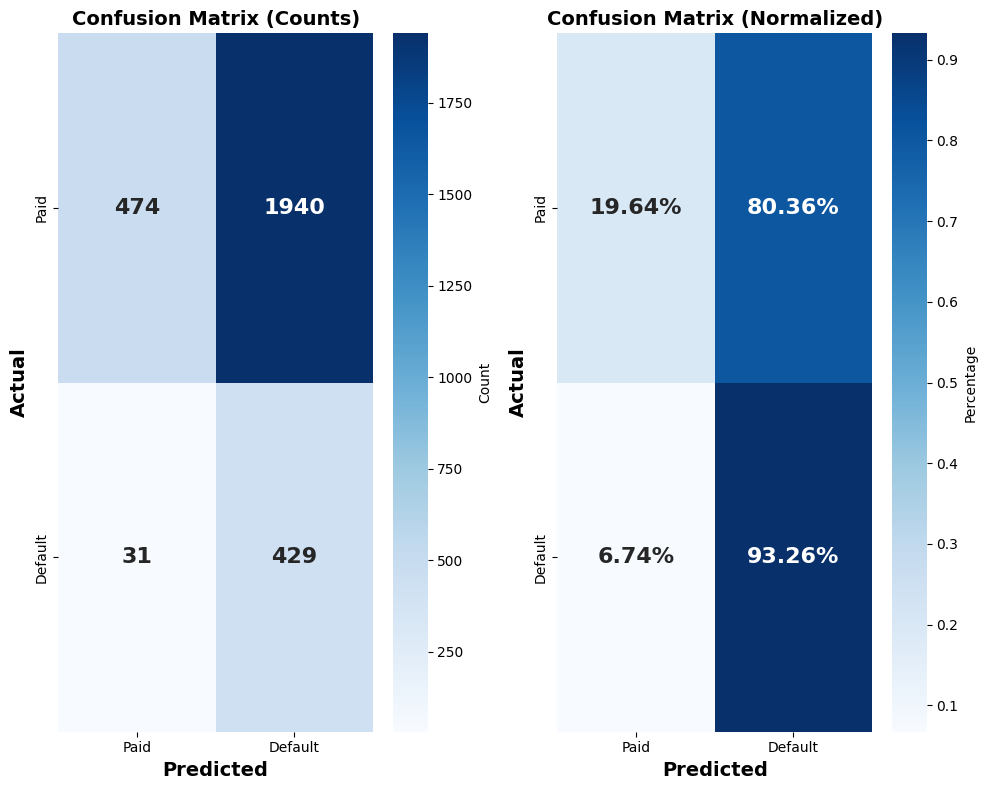

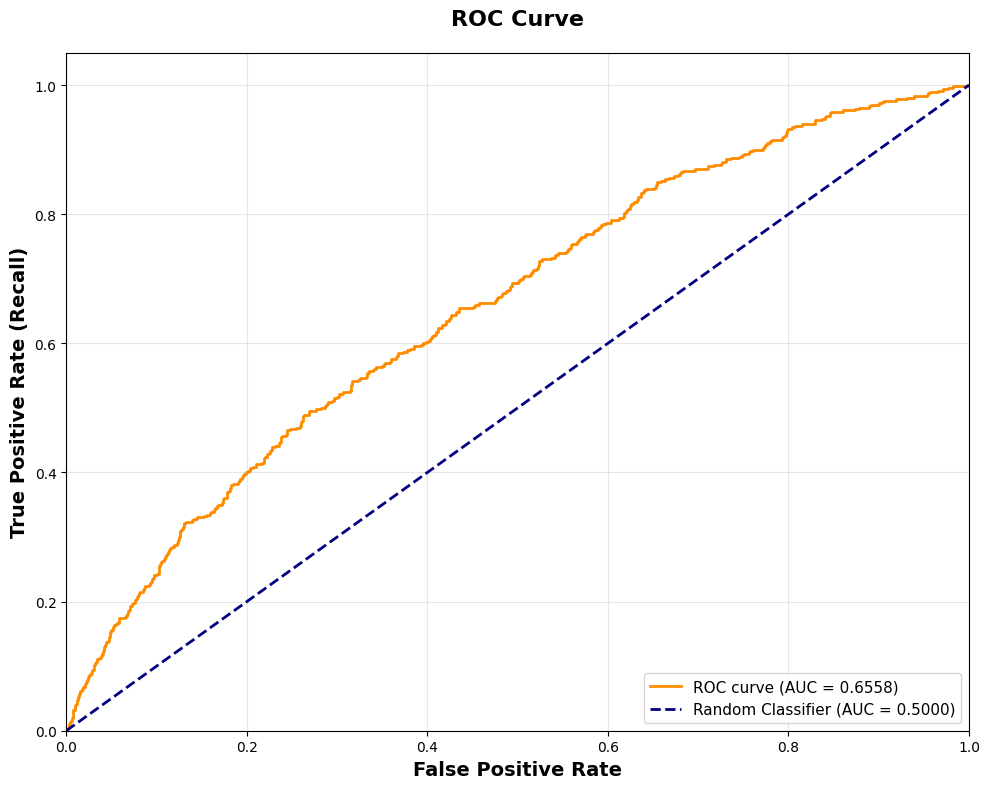

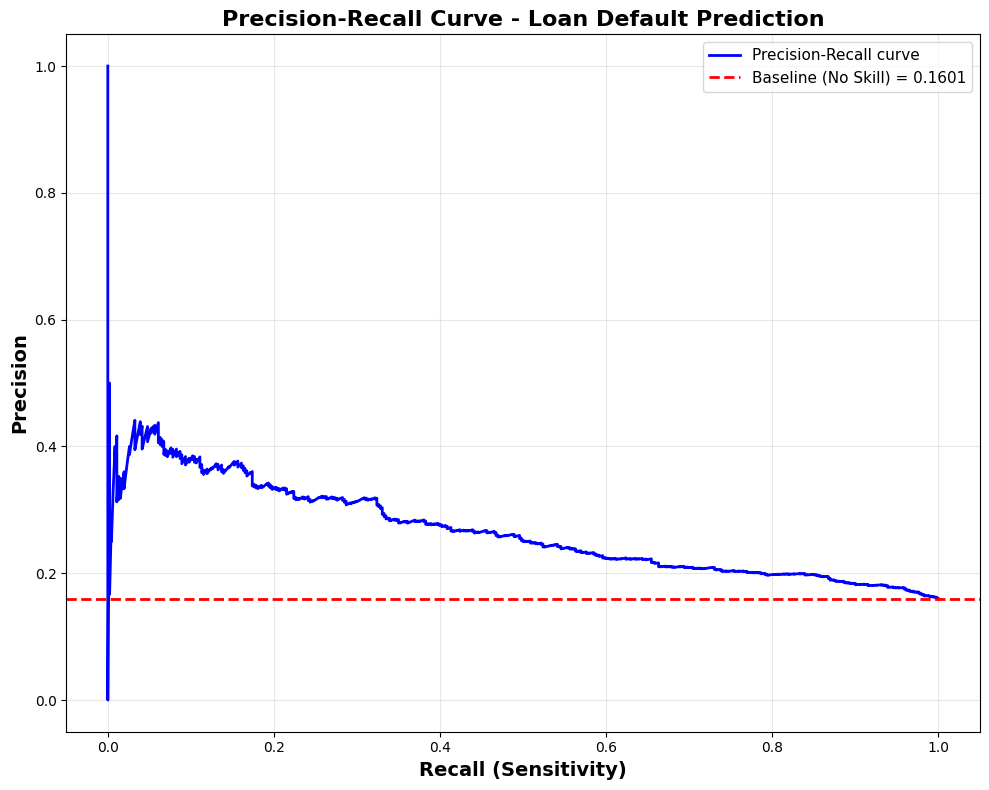

In [60]:
# Comprehensive evaluation
model = comparison.get_best_model()
X_test = data.X_test
y_test = data.y_test
results = me.evaluate_model_comprehensive(
    model, X_test, y_test,
    class_names=['Paid', 'Default'], usr_title="Loan Default Prediction",
    optimize_for=mo.OptimizationMetric.RECALL_WEIGHTED
)

In [61]:
# # Prepare data with engineered features
# print("\nPreparing data with engineered features...")
#
# # One-hot encode
# df_fe_encoded = pd.get_dummies(df_fe, columns=['purpose'], drop_first=True, dtype=int)
#
# # Split features and target
# X_fe = df_fe_encoded.drop('not.fully.paid', axis=1)
# y_fe = df_fe_encoded['not.fully.paid']
#
# # Train-test split
# X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
#     X_fe, y_fe, test_size=0.3, random_state=42, stratify=y_fe
# )
#
# # Scale features
# scaler_fe = StandardScaler()
# X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
# X_test_fe_scaled = scaler_fe.transform(X_test_fe)
#
# print(f"  ✓ Feature matrix shape: {X_train_fe_scaled.shape}")
# print(f"  ✓ Ready for modeling!")

# Test out model comparison

In [62]:
# import lib.model_comparison as mc
#
# # Prepare data
# data = mc.ComparisonInput(
#     X_train=data.X_train,
#     y_train=data.y_train,
#     X_test=data.X_test,
#     y_test=data.y_test,
#     X_val=data.X_val,
#     y_val=data.y_val,
#     class_names=['Paid', 'Default']
# )
#
# # Option 1: Use default configurations
# configs = mc.create_default_configs(
#     use_neural_network=True,
#     use_random_forest=True,
#     use_xgboost=True,
#     class_weight='balanced'
# )
#
# # Option 2: Custom configuration
# configs = [
#     mc.ModelConfig(
#         model_type=mc.ModelType.RANDOM_FOREST,
#         name="RF_Custom",
#         params={'n_estimators': 200, 'max_depth': 15},
#         class_weight='balanced'
#     ),
#     mc.ModelConfig(
#         model_type=mc.ModelType.NEURAL_NETWORK,
#         name="NN_Deep",
#         params={'layers': [64, 32, 16], 'dropout_rate': 0.4}
#     )
# ]
#
# # Compare all models
# comparison = mc.compare_models(
#     configs=configs,
#     data=data,
#     optimize_for='f1',  # or 'recall', 'roc_auc', etc.
#     verbose=True
# )
#
# # Access results
# comparison.print_comparison()
# best_model = comparison.get_best_model()
# best_result = comparison.get_best_result()
# best_result.summary()
#
# # Access individual results
# rf_result = comparison.results['Random Forest']
# print(f"RF ROC-AUC: {rf_result.roc_auc:.4f}")


## Random Forest Classifier

Random Forest often outperforms neural networks on tabular data:

In [63]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, roc_auc_score
#
# tu.print_heading("RANDOM FOREST MODEL")
#
# print("\nTraining Random Forest...")
#
# # Train Random Forest with class weights
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     min_samples_split=50,
#     min_samples_leaf=20,
#     class_weight='balanced',  # Handle imbalance
#     random_state=42,
#     n_jobs=-1,  # Use all CPU cores
#     verbose=0
# )
#
# rf_model.fit(X_train_fe_scaled, y_train_fe)
#
# # Predictions
# rf_pred_proba = rf_model.predict_proba(X_test_fe_scaled)[:, 1]
# rf_pred = rf_model.predict(X_test_fe_scaled)
#
# # Evaluate
# rf_auc = roc_auc_score(y_test_fe, rf_pred_proba)
#
# print(tu.bold_and_colored_text("\n✓ Training Complete!", tu.Color.GREEN))
# print(f"\nRandom Forest Performance:")
# print(f"  AUC-ROC: {rf_auc:.4f}")
# print(f"\nClassification Report:")
# print(classification_report(y_test_fe, rf_pred, target_names=['Paid', 'Default'], zero_division=0))

In [64]:
# # Random Forest - Business Impact Calculation
# from sklearn.metrics import confusion_matrix
#
# tu.print_heading("RANDOM FOREST - BUSINESS IMPACT METRICS")
#
# # Calculate confusion matrix
# rf_cm = confusion_matrix(y_test_fe, rf_pred)
# rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()
#
# # Calculate key metrics
# rf_defaults_caught = rf_tp
# rf_total_defaults = rf_tp + rf_fn
# rf_recall_pct = (rf_defaults_caught / rf_total_defaults) * 100
# baseline_catch_rate = class_percentages[1]  # Random chance = % of defaults in dataset
#
# print(f"\nConfusion Matrix:")
# print(rf_cm)
# print(f"\nDetailed Breakdown:")
# print(f"  True Negatives (TN):  {rf_tn:,} - Correctly predicted as Paid")
# print(f"  False Positives (FP): {rf_fp:,} - Incorrectly predicted as Default")
# print(f"  False Negatives (FN): {rf_fn:,} - Missed Defaults (COSTLY!)")
# print(f"  True Positives (TP):  {rf_tp:,} - Correctly Caught Defaults")
#
# print(f"\n" + "=" * 70)
# print(tu.bold_text("BUSINESS IMPACT SUMMARY:"))
# print(f"  Baseline (random):         Catch ~{baseline_catch_rate:.0f}% of defaults by chance")
# print(f"  Our Random Forest Model:   Catch ~{rf_recall_pct:.0f}% of defaults")
# print(f"  Defaults Caught:           {rf_defaults_caught} out of {rf_total_defaults}")
# print(f"  Improvement over baseline: {rf_recall_pct - baseline_catch_rate:.1f} percentage points")
# print(f"\n  Assuming $15,000 average loan:")
# print(f"  Potential Loss Prevention: ${rf_defaults_caught * 15000:,}")
# print(f"=" * 70)


In [65]:
# # Feature Importance
# tu.print_heading("FEATURE IMPORTANCE ANALYSIS")
#
# feature_importance = pd.DataFrame({
#     'feature': X_fe.columns,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)
#
# print("\nTop 15 Most Important Features:")
# print(feature_importance.head(15).to_string(index=False))
#
# # Visualize
# plt.figure(figsize=(12, 8))
# top_features = feature_importance.head(15)
# plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
# plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
# plt.ylabel('Feature', fontsize=12, fontweight='bold')
# plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold', pad=20)
# plt.gca().invert_yaxis()
# plt.grid(axis='x', alpha=0.3)
# plt.tight_layout()
# plt.show()

## 3. XGBoost Classifier

XGBoost is the industry standard for tabular data competitions:

In [66]:
# tu.print_heading("XGBOOST MODEL")
#
# print("\nTraining XGBoost...")
#
# # Calculate scale_pos_weight for imbalance
# scale_pos_weight = (y_train_fe == 0).sum() / (y_train_fe == 1).sum()
#
# # Train XGBoost
# xgb_model = xgb.XGBClassifier(
#     n_estimators=100,
#     max_depth=6,
#     learning_rate=0.1,
#     scale_pos_weight=scale_pos_weight,  # Handle imbalance
#     random_state=42,
#     n_jobs=-1,
#     eval_metric='logloss'
# )
#
# xgb_model.fit(X_train_fe_scaled, y_train_fe, verbose=False)
#
# # Predictions
# xgb_pred_proba = xgb_model.predict_proba(X_test_fe_scaled)[:, 1]
# xgb_pred = xgb_model.predict(X_test_fe_scaled)
#
# # Evaluate
# xgb_auc = roc_auc_score(y_test_fe, xgb_pred_proba)
#
# print(tu.bold_and_colored_text("\n✓ Training Complete!", tu.Color.GREEN))
# print(f"\nXGBoost Performance:")
# print(f"  AUC-ROC: {xgb_auc:.4f}")
# print(f"\nClassification Report:")
# print(classification_report(y_test_fe, xgb_pred, target_names=['Paid', 'Default'], zero_division=0))

## 4. Model Comparison

Compare all models to find the best performer:

In [67]:
# tu.print_heading("MODEL COMPARISON")
#
# # Compile results
# comparison_data = {
#     'Model': ['Neural Network (Baseline)', 'Random Forest'],
#     'AUC-ROC': [auc, rf_auc],
#     'Features': ['Original (17)', f'Engineered ({X_fe.shape[1]})']
# }
#
# comparison_data['Model'].append('XGBoost')
# comparison_data['AUC-ROC'].append(xgb_auc)
# comparison_data['Features'].append(f'Engineered ({X_fe.shape[1]})')
#
# comparison_df = pd.DataFrame(comparison_data)
# comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
# comparison_df['Rank'] = range(1, len(comparison_df) + 1)
# comparison_df = comparison_df[['Rank', 'Model', 'Features', 'AUC-ROC']]
#
# print("\nModel Performance Ranking:")
# print("=" * 70)
# print(comparison_df.to_string(index=False))
# print("=" * 70)
#
# # Highlight best model
# best_model = comparison_df.iloc[0]
# improvement = ((best_model['AUC-ROC'] - auc) / auc) * 100
#
# print(f"\n🏆 BEST MODEL: {best_model['Model']}")
# print(f"   AUC-ROC: {best_model['AUC-ROC']:.4f}")
# if improvement > 0:
#     print(f"   Improvement over baseline: +{improvement:.1f}%")
# else:
#     print(f"   Baseline performance maintained")
#
# # Visualize
# plt.figure(figsize=(10, 6))
# colors = ['gold' if i == 0 else 'steelblue' for i in range(len(comparison_df))]
# plt.barh(comparison_df['Model'], comparison_df['AUC-ROC'], color=colors, edgecolor='black', linewidth=2)
# plt.xlabel('AUC-ROC Score', fontsize=12, fontweight='bold')
# plt.ylabel('Model', fontsize=12, fontweight='bold')
# plt.title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
# plt.xlim([0.5, 1.0])
#
# # Add value labels
# for i, (model, score) in enumerate(zip(comparison_df['Model'], comparison_df['AUC-ROC'])):
#     plt.text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold', fontsize=11)
#
# plt.grid(axis='x', alpha=0.3)
# plt.tight_layout()
# plt.show()